# CSCAS baseline comparison

Compares eight baselines evaluated on the identical CSCAS train/test split and training-pool protocol (see `baselines/cscas.py`, `baselines/cscas_base.py`, `baselines/cscas_mining.py`, `baselines/cscas_logreg.py`, `baselines/cscas_xgboost.py`, `baselines/cscas_bert.py`, `baselines/cscas_securebert.py`, `baselines/cscas_zeroshot.py`):

1. **Paper** -- the CSCAS paper's own 42 raw features, `RandomForestClassifier`
2. **Base schema (RF)** -- this project's 5-feature reduced `base` schema (paper's features minus `SignatureID`, `SCAS`, and every `*Similarity` column -- none of those are things a real deployment could compute for a fresh alert without already knowing the answer or running CSCAS's offline similarity pipeline), `RandomForestClassifier`
3. **Base schema + Mining (RF)** -- the same 5-feature base schema extended with symbolic features mined by the attribute-mining pipeline (contrast-set + decision-tree rules) on the identical train split, `RandomForestClassifier`. Mining excludes the same SCAS/Similarity-derived fields as the base schema, for the same realism reason.
4. **Base schema (LogReg)** -- same reduced base schema, `LogisticRegression` (`StandardScaler` + missingness flags for the `-1` sentinel columns)
5. **Base schema (XGBoost)** -- same reduced base schema, `XGBClassifier`
6. **BERT** -- same 6 reduced fields (no `SignatureID`/`SCAS`/`Similarity`) serialized to text, fine-tuned DistilBERT
7. **SecureBERT** -- same 6 fields, fine-tuned SecureBERT 2.0 (ModernBERT architecture, domain-adapted)
8. **Zero-shot** -- same 6 fields serialized to a prompt, Llama-3.1-8B-Instruct, no fine-tuning

The first seven (paper, base RF, base + mining, LogReg, XGBoost, BERT, SecureBERT) all report all **three training-pool conditions**: random undersampling, class-weighted/natural-ratio, and guided by CSCAS's SCAS outlier clusters. All trainable methods evaluate on the same shared eval subsample (the paper-replication script is the one exception, staying on the full test set to match the published protocol). Zero-shot has no training step, so none of the three conditions apply to it -- it reports a single flat precision/recall/f1 from one deterministic run against the shared eval subsample.

**Run the scripts first** to generate the `results/*.json` files this notebook reads:
```
cd src/thesis/baselines
python cscas.py
python cscas_base.py
python cscas_mining.py
python cscas_logreg.py
python cscas_xgboost.py
python cscas_bert.py
python cscas_securebert.py
python cscas_zeroshot.py
```

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from thesis.baselines._results import RESULTS_DIR, is_zero_shot, load_baseline_results

## Settings

Edit and re-run -- nothing past this cell needs to change.

In [2]:
RESULT_NAMES = [
    "cscas",
    "cscas_base",
    "cscas_mining",
    "cscas_logreg",
    "cscas_xgboost",
    "cscas_bert",
    "cscas_securebert",
    "cscas_zeroshot",
]

LABELS = {
    "cscas": "Paper (42 features, RF)",
    "cscas_base": "Base schema (RF)",
    "cscas_mining": "Base schema + Mining (RF)",
    "cscas_logreg": "Base schema (LogReg)",
    "cscas_xgboost": "Base schema (XGBoost)",
    "cscas_bert": "BERT (6 fields as text)",
    "cscas_securebert": "SecureBERT 2.0 (6 fields as text)",
    "cscas_zeroshot": "Zero-shot (Llama-3.1-8B-Instruct)",
}

COLORS = {
    "cscas": "#4477AA",
    "cscas_base": "#CCBB44",
    "cscas_mining": "#EE8866",
    "cscas_logreg": "#228833",
    "cscas_xgboost": "#66CCEE",
    "cscas_bert": "#EE6677",
    "cscas_securebert": "#AA3377",
    "cscas_zeroshot": "#BBBBBB",
}

# Where this notebook's own outputs go -- separate from the *.json the
# baseline scripts write, but alongside them: figures/ subdir for plots,
# summary CSV directly in RESULTS_DIR.
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
results = {}
for name in RESULT_NAMES:
    try:
        results[name] = load_baseline_results(name)
    except FileNotFoundError as e:
        print(f"[skip] {e}")

print(f"Loaded results for: {list(results.keys())}")

Loaded results for: ['cscas', 'cscas_base', 'cscas_mining', 'cscas_logreg', 'cscas_xgboost', 'cscas_bert', 'cscas_securebert', 'cscas_zeroshot']


In [4]:
def plot_baseline(condition_key: str, title: str) -> None:
    """Grouped bar chart across every loaded method that actually reports
    `condition_key` -- excludes zero-shot always (flat shape, no
    conditions -- see plot_zeroshot() below). Every trainable method now
    reports all three conditions, so this naturally includes everything
    that's loaded. Saves to FIGURES_DIR/{condition_key}.png before
    displaying."""
    metrics = ["precision", "recall", "f1"]
    methods = [
        n for n in RESULT_NAMES
        if n in results and not is_zero_shot(results[n]) and condition_key in results[n]
    ]
    if not methods:
        print(f"No results loaded with a '{condition_key}' condition -- run the baseline scripts first.")
        return

    x = np.arange(len(metrics))
    width = 0.85 / len(methods)

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, name in enumerate(methods):
        values = [results[name][condition_key][m] for m in metrics]
        offset = (i - (len(methods) - 1) / 2) * width
        bars = ax.bar(
            x + offset, values, width,
            label=LABELS.get(name, name), color=COLORS.get(name),
        )
        ax.bar_label(bars, fmt="%.2f", fontsize=7, padding=2, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels([m.capitalize() for m in metrics])
    ax.set_ylim(0, 1.2)
    ax.set_ylabel("Score")
    ax.set_title(title)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    save_path = FIGURES_DIR / f"{condition_key}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Figure written to {save_path}")

    plt.show()

## Random undersampling

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/random.png


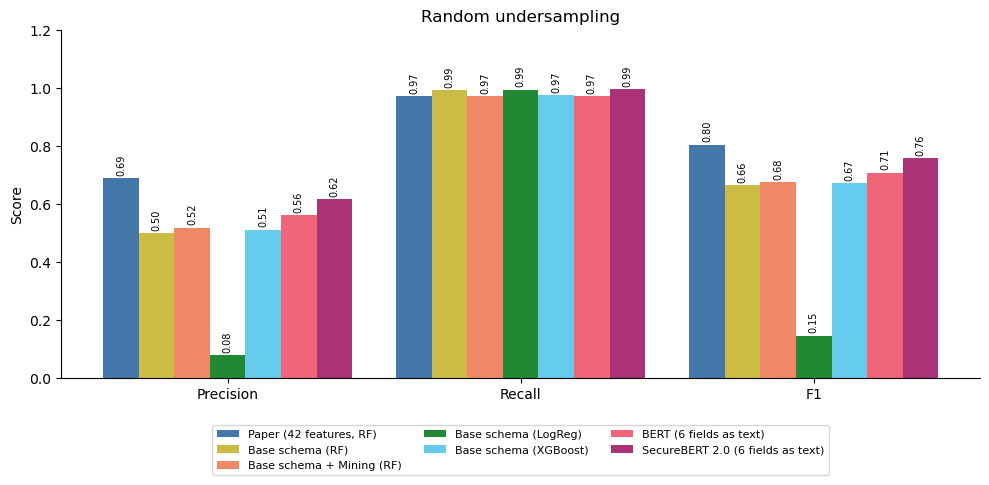

In [5]:
plot_baseline("random", "Random undersampling")

## Class-weighted (natural-ratio)

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/class_weighted.png


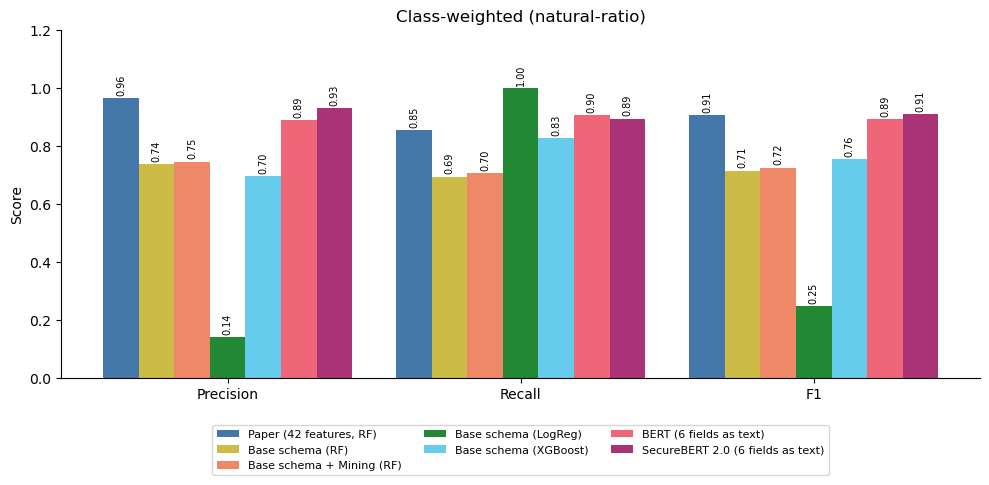

In [6]:
plot_baseline("class_weighted", "Class-weighted (natural-ratio)")

## Guided by CSCAS

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/guided.png


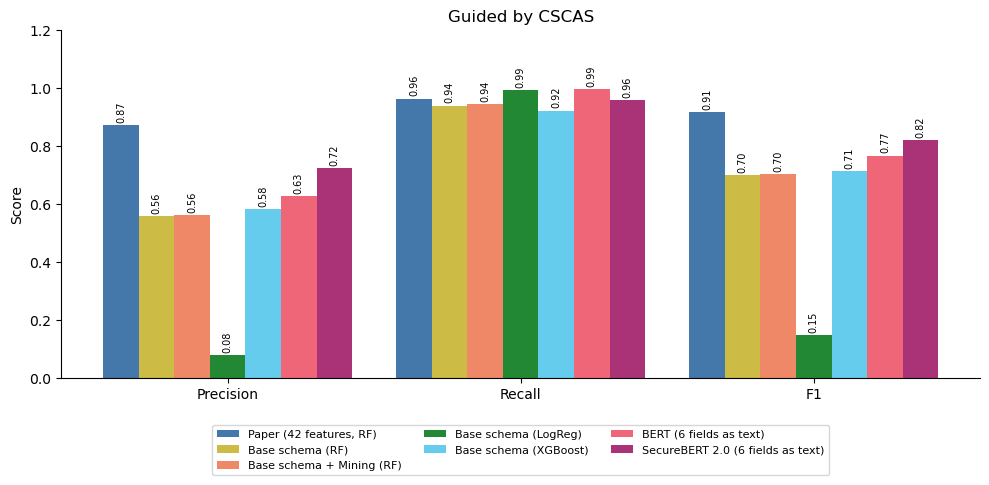

In [7]:
plot_baseline("guided", "Guided by CSCAS")

## Zero-shot

The one method without the three-condition structure (no training pool, no seeds) -- a single bar per metric from one deterministic run, not comparable to `plot_baseline()`'s per-condition grouped bars above.

Figure written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/figures/zeroshot.png


/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_93442/2143097590.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.capitalize() for m in metrics])


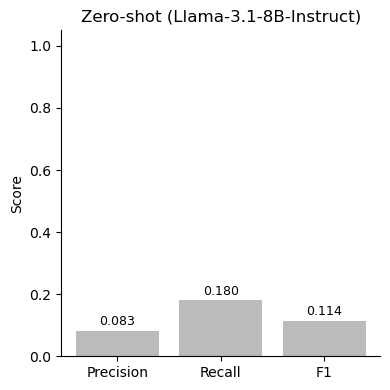

In [8]:
def plot_zeroshot() -> None:
    name = "cscas_zeroshot"
    if name not in results or not is_zero_shot(results[name]):
        print("No zero-shot results loaded -- run cscas_zeroshot.py first.")
        return

    metrics = ["precision", "recall", "f1"]
    data = results[name]
    values = [data[m] for m in metrics]

    fig, ax = plt.subplots(figsize=(4, 4))
    bars = ax.bar(metrics, values, color=COLORS.get(name))
    ax.bar_label(bars, fmt="%.3f", fontsize=9, padding=2)

    ax.set_xticklabels([m.capitalize() for m in metrics])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(LABELS.get(name, name))
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

    save_path = FIGURES_DIR / "zeroshot.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Figure written to {save_path}")

    plt.show()


plot_zeroshot()

## Summary table

Tidy view of all loaded results -- handy to copy straight into a slide.

In [9]:
CONDITION_LABELS = {
    "random": "Random undersampling",
    "class_weighted": "Class-weighted (natural-ratio)",
    "guided": "Guided by CSCAS",
}

rows = []
for name, data in results.items():
    if is_zero_shot(data):
        rows.append({
            "method": LABELS.get(name, name),
            "condition": "(no training)",
            "precision": data["precision"],
            "recall": data["recall"],
            "f1": data["f1"],
        })
    else:
        for condition_key, condition_label in CONDITION_LABELS.items():
            if condition_key not in data:
                continue  # defensive: every trainable method reports all three today
            rows.append({
                "method": LABELS.get(name, name),
                "condition": condition_label,
                "precision": data[condition_key]["precision"],
                "recall": data[condition_key]["recall"],
                "f1": data[condition_key]["f1"],
            })

if not rows:
    print("No results loaded -- run the baseline scripts first.")
    summary_df = pd.DataFrame(columns=["method", "condition", "precision", "recall", "f1"])
else:
    summary_df = pd.DataFrame(rows).sort_values(["condition", "method"]).reset_index(drop=True)
    summary_csv_path = RESULTS_DIR / "cscas_baseline_summary.csv"
    summary_df.to_csv(summary_csv_path, index=False)
    print(f"Summary written to {summary_csv_path}")
summary_df

Summary written to /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/baselines/results/cscas_baseline_summary.csv


,method,condition,precision,recall,f1
0,Zero-shot (Llama-3.1-8B-Instruct),(no training),0.082956,0.179739,0.113519
1,BERT (6 fields as text),Class-weighted (natural-ratio),0.888308,0.904575,0.892974
2,Base schema (LogReg),Class-weighted (natural-ratio),0.140949,1.000000,0.247073
3,Base schema (RF),Class-weighted (natural-ratio),0.736482,0.693464,0.714170
4,Base schema (XGBoost),Class-weighted (natural-ratio),0.695055,0.826797,0.755224
5,Base schema + Mining (RF),Class-weighted (natural-ratio),0.745578,0.704575,0.724457
6,"Paper (42 features, RF)",Class-weighted (natural-ratio),0.964975,0.853724,0.905910
7,SecureBERT 2.0 (6 fields as text),Class-weighted (natural-ratio),0.930028,0.893464,0.909880
8,BERT (6 fields as text),Guided by CSCAS,0.627362,0.994118,0.765928
9,Base schema (LogReg),Guided by CSCAS,0.078571,0.990850,0.145597
